# EDA F1 Podium Prediction
**Author:** Azzam  
**Dataset:** Ergast F1 (1950–2026)  
**Goal:** Exploratory Data Analysis untuk membangun model prediksi podium (P1-P3)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

DATA_PATH = "D:/Projects/f1-podium-prediction/data/"

# Load all datasets
tables = {
    "circuits": pd.read_csv(DATA_PATH + "circuits.csv", na_values="\\N"),
    "constructor_results": pd.read_csv(DATA_PATH + "constructor_results.csv", na_values="\\N"),
    "constructor_standings": pd.read_csv(DATA_PATH + "constructor_standings.csv", na_values="\\N"),
    "constructors": pd.read_csv(DATA_PATH + "constructors.csv", na_values="\\N"),
    "driver_standings": pd.read_csv(DATA_PATH + "driver_standings.csv", na_values="\\N"),
    "drivers": pd.read_csv(DATA_PATH + "drivers.csv", na_values="\\N"),
    "lap_times": pd.read_csv(DATA_PATH + "lap_times.csv", na_values="\\N"),
    "pit_stops": pd.read_csv(DATA_PATH + "pit_stops.csv", na_values="\\N"),
    "qualifying": pd.read_csv(DATA_PATH + "qualifying.csv", na_values="\\N"),
    "races": pd.read_csv(DATA_PATH + "races.csv", na_values="\\N"),
    "results": pd.read_csv(DATA_PATH + "results.csv", na_values="\\N"),
    "seasons": pd.read_csv(DATA_PATH + "seasons.csv", na_values="\\N"),
    "sprint_results": pd.read_csv(DATA_PATH + "sprint_results.csv", na_values="\\N"),
    "status": pd.read_csv(DATA_PATH + "status.csv", na_values="\\N"),
}
for name, df in tables.items():
    print(f"{name:25s} → {df.shape[0]:>7,} rows × {df.shape[1]:>2d} cols")


circuits                  →      78 rows ×  9 cols
constructor_results       →  12,953 rows ×  5 cols
constructor_standings     →  13,719 rows ×  7 cols
constructors              →     214 rows ×  5 cols
driver_standings          →  35,537 rows ×  7 cols
drivers                   →     865 rows ×  9 cols
lap_times                 → 875,093 rows ×  6 cols
pit_stops                 →  22,424 rows ×  7 cols
qualifying                →  11,146 rows ×  9 cols
races                     →   1,171 rows × 18 cols
results                   →  27,414 rows × 18 cols
seasons                   →      77 rows ×  2 cols
sprint_results            →     546 rows × 17 cols
status                    →     140 rows ×  2 cols


---
# 1. Data Overview
Overview dari setiap tabel: shape, tipe data, missing values.


In [2]:
def overview(df, name):
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"  Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f"  Missing values:")
        for col, n in missing.items():
            print(f"    {col}: {n} ({n/len(df)*100:.1f}%)")
    else:
        print(f"  No missing values")
    print()

for name, df in tables.items():
    overview(df, name)



  circuits
  Shape: 78 rows × 9 cols
  Memory: 0.0 MB
  No missing values


  constructor_results
  Shape: 12,953 rows × 5 cols
  Memory: 0.5 MB
  Missing values:
    status: 12936 (99.9%)


  constructor_standings
  Shape: 13,719 rows × 7 cols
  Memory: 0.7 MB
  Missing values:
    position: 1 (0.0%)


  constructors
  Shape: 214 rows × 5 cols
  Memory: 0.0 MB
  No missing values


  driver_standings
  Shape: 35,537 rows × 7 cols
  Memory: 2.0 MB
  Missing values:
    position: 13 (0.0%)


  drivers
  Shape: 865 rows × 9 cols
  Memory: 0.1 MB
  Missing values:
    number: 802 (92.7%)
    code: 757 (87.5%)


  lap_times
  Shape: 875,093 rows × 6 cols
  Memory: 46.7 MB
  No missing values


  pit_stops
  Shape: 22,424 rows × 7 cols
  Memory: 1.5 MB
  Missing values:
    duration: 3 (0.0%)
    milliseconds: 3 (0.0%)


  qualifying
  Shape: 11,146 rows × 9 cols
  Memory: 0.9 MB
  Missing values:
    q1: 164 (1.5%)
    q2: 4818 (43.2%)
    q3: 7204 (64.6%)


  races
  Shape: 1,171 rows × 

In [3]:
# Preview beberapa baris pertama tiap tabel
for name, df in tables.items():
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    display(df.head(3))



  circuits


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.9680,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.7380,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.5106,7,http://en.wikipedia.org/wiki/Bahrain_Internati...



  constructor_results


,constructorResultsId,raceId,constructorId,points,status
0,1,18,1,14.0,NaN
1,2,18,2,8.0,NaN
2,3,18,3,9.0,NaN



  constructor_standings


...

,year,url
0,2009,http://en.wikipedia.org/wiki/2009_Formula_One_...
1,2008,http://en.wikipedia.org/wiki/2008_Formula_One_...
2,2007,http://en.wikipedia.org/wiki/2007_Formula_One_...



  sprint_results


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId,rank
0,1,1061,830,9,33,2,1.0,1,1,3,17,25:38.426,1538426.0,14.0,1:30.013,1.0,NaN
1,2,1061,1,131,44,1,2.0,2,2,2,17,+1.430,1539856.0,17.0,1:29.937,1.0,NaN
2,3,1061,822,131,77,3,3.0,3,3,1,17,+7.502,1545928.0,17.0,1:29.958,1.0,NaN



  status


,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident


---
# 2. Temporal Coverage
Distribusi race per tahun dan rentang dataset.


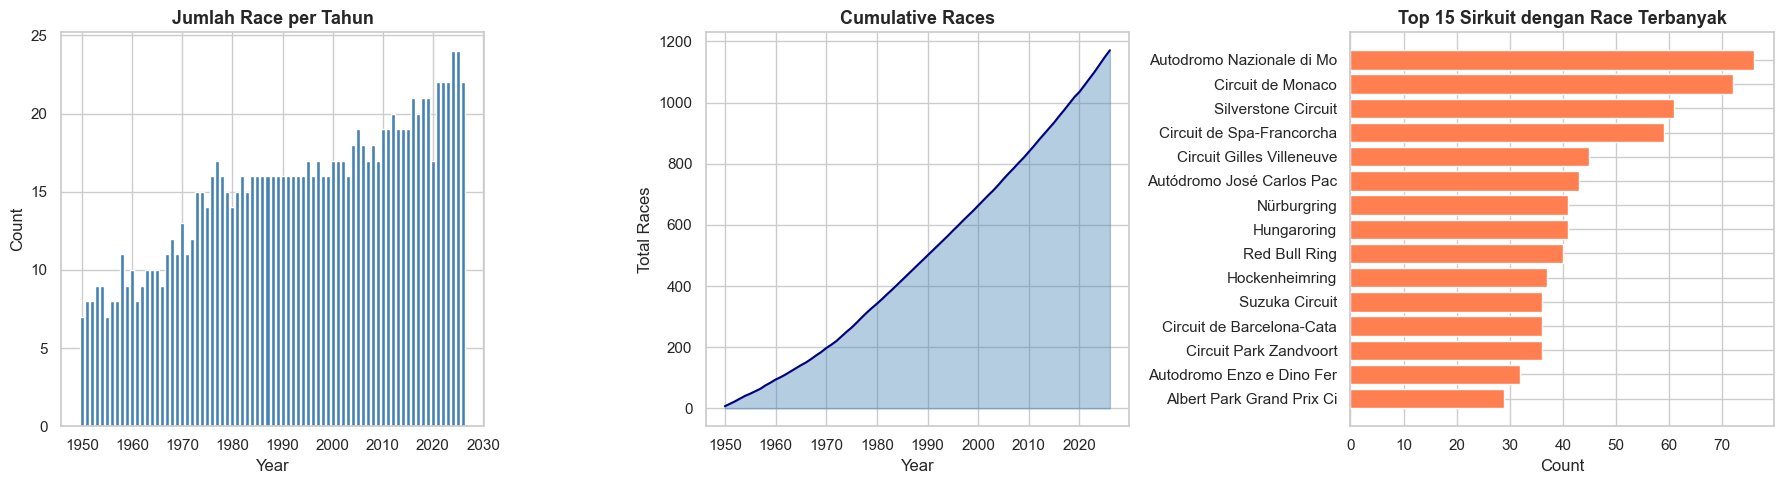

Rentang tahun: 1950 – 2026
Total race: 1,171
Total sirkuit: 78

Ketersediaan data per dekade:
  lap_times           : 1982 – 2026  (800 races)
  pit_stops           : 1994 – 2026  (605 races)
  qualifying          : 1994 – 2026  (526 races)
  sprint_results      : 2021 – 2026  (27 races)


In [4]:
# Parse date
races = tables["races"].copy()
races["date"] = pd.to_datetime(races["date"])
races["year"] = races["date"].dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Race count per year
yearly = races.groupby("year").size()
axes[0].bar(yearly.index, yearly.values, color="steelblue", width=0.8)
axes[0].set_title("Jumlah Race per Tahun", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

# Cumulative races
cum = yearly.cumsum()
axes[1].fill_between(cum.index, cum.values, alpha=0.4, color="steelblue")
axes[1].plot(cum.index, cum.values, color="navy", linewidth=1.5)
axes[1].set_title("Cumulative Races", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Total Races")

# Races per circuit
top_circuits = races.groupby("circuitId").size().sort_values(ascending=False).head(15)
circuit_names = dict(zip(tables["circuits"]["circuitId"], tables["circuits"]["name"]))
top_circuits.index = [circuit_names.get(i, f"ID {i}") for i in top_circuits.index]
bars = axes[2].barh(range(len(top_circuits)), top_circuits.values, color="coral")
axes[2].set_yticks(range(len(top_circuits)))
axes[2].set_yticklabels([s[:25] for s in top_circuits.index])
axes[2].set_title("Top 15 Sirkuit dengan Race Terbanyak", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Count")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Rentang tahun: {races['year'].min()} – {races['year'].max()}")
print(f"Total race: {len(races):,}")
print(f"Total sirkuit: {tables['circuits'].shape[0]}")

# Sebaran data per tabel per tahun
print("\nKetersediaan data per dekade:")
results = tables["results"].merge(races[["raceId", "year"]], on="raceId")
for name in ["lap_times", "pit_stops", "qualifying", "sprint_results"]:
    df = tables[name].merge(races[["raceId", "year"]], on="raceId")
    yr_range = f"{df['year'].min()} – {df['year'].max()}"
    coverage = len(df["raceId"].unique())
    print(f"  {name:20s}: {yr_range}  ({coverage:,} races)")


---
# 3. Driver Demographics
Analisis demografi driver: kebangsaan, usia, pengalaman.


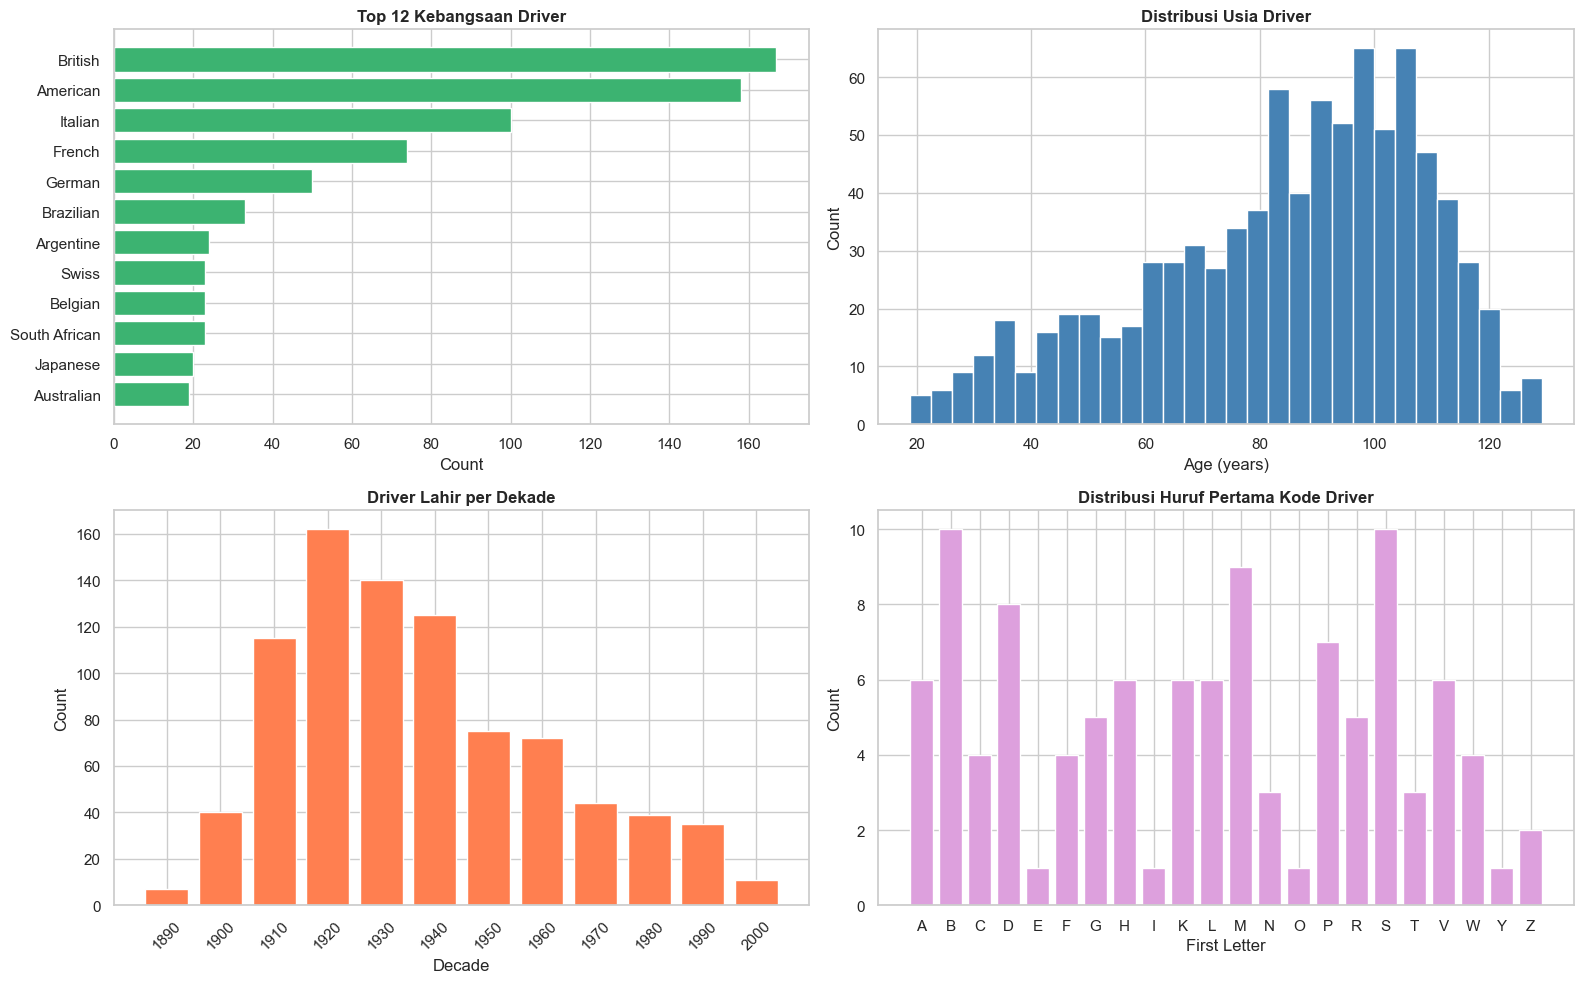

Total driver unik: 865
Negara terbanyak: British (167)


In [5]:
drivers = tables["drivers"].copy()
drivers["dob"] = pd.to_datetime(drivers["dob"], errors="coerce")
drivers["age"] = (pd.Timestamp("2026-06-01") - drivers["dob"]).dt.days / 365.25

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top nationalities
top_nat = drivers["nationality"].value_counts().head(12)
axes[0,0].barh(range(len(top_nat)), top_nat.values, color="mediumseagreen")
axes[0,0].set_yticks(range(len(top_nat)))
axes[0,0].set_yticklabels(top_nat.index)
axes[0,0].set_title("Top 12 Kebangsaan Driver", fontweight="bold")
axes[0,0].set_xlabel("Count")
axes[0,0].invert_yaxis()

# Age distribution
drivers["age"].hist(bins=30, ax=axes[0,1], color="steelblue", edgecolor="white")
axes[0,1].set_title("Distribusi Usia Driver", fontweight="bold")
axes[0,1].set_xlabel("Age (years)")
axes[0,1].set_ylabel("Count")

# Driver birth decade
drivers["decade"] = (drivers["dob"].dt.year // 10) * 10
decade_counts = drivers["decade"].value_counts().sort_index()
axes[1,0].bar(decade_counts.index.astype(str), decade_counts.values, color="coral")
axes[1,0].set_title("Driver Lahir per Dekade", fontweight="bold")
axes[1,0].set_xlabel("Decade")
axes[1,0].set_ylabel("Count")
axes[1,0].tick_params(axis="x", rotation=45)

# Driver code distribution (first letter)
codes = drivers["code"].dropna().str[0].value_counts().sort_index()
axes[1,1].bar(codes.index, codes.values, color="plum")
axes[1,1].set_title("Distribusi Huruf Pertama Kode Driver", fontweight="bold")
axes[1,1].set_xlabel("First Letter")
axes[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Total driver unik: {drivers['driverId'].nunique():,}")
print(f"Negara terbanyak: {drivers['nationality'].value_counts().index[0]} ({drivers['nationality'].value_counts().values[0]})")


---
# 4. Constructor Analysis
Analisis tim/constructor sepanjang sejarah F1.


  1950s: Ferrari (30w), Alfa Romeo (11w), Vanwall (10w)
  1960s: Lotus-Climax (22w), Ferrari (13w), BRM (12w)
  1970s: Ferrari (37w), Team Lotus (35w), Tyrrell (21w)
  1980s: McLaren (56w), Williams (37w), Ferrari (18w)
  1990s: Williams (61w), McLaren (43w), Ferrari (28w)
  2000s: Ferrari (85w), McLaren (41w), Renault (20w)
  2010s: Mercedes (93w), Red Bull (56w), Ferrari (28w)
  2020s: Red Bull (68w), Mercedes (36w), McLaren (21w)


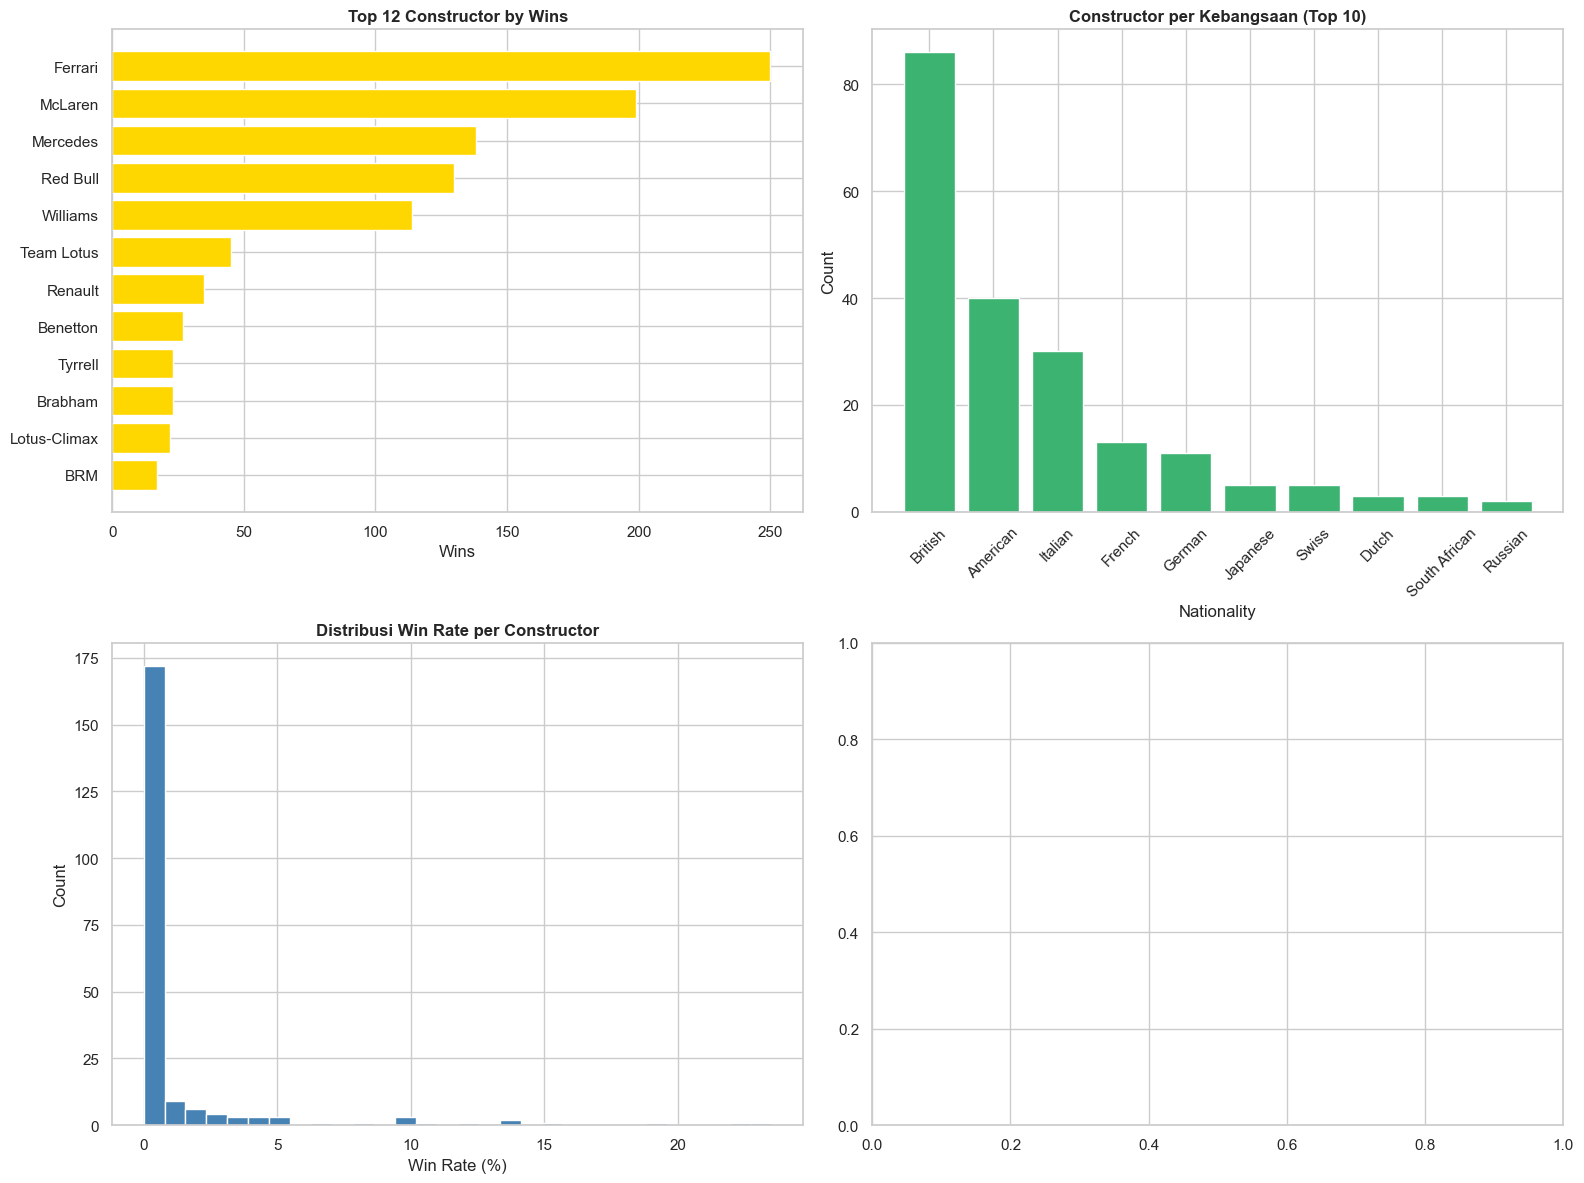

In [6]:
constructors = tables["constructors"].copy()
results = tables["results"].copy()

# Merge untuk hitung wins & podiums
results_full = results.merge(tables["races"][["raceId", "year"]], on="raceId")
results_full = results_full.merge(constructors[["constructorId", "name", "nationality"]], on="constructorId")

# Constructor stats
cons_stats = results_full.groupby("constructorId").agg(
    races=("resultId", "count"),
    wins=("positionOrder", lambda x: (x == 1).sum()),
    podiums=("positionOrder", lambda x: (x <= 3).sum()),
    avg_pos=("positionOrder", "mean")
).reset_index()
cons_stats = cons_stats.merge(constructors[["constructorId", "name", "nationality"]], on="constructorId")
cons_stats["win_rate"] = cons_stats["wins"] / cons_stats["races"] * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top constructors by wins
top_wins = cons_stats.sort_values("wins", ascending=False).head(12)
bars0 = axes[0,0].barh(range(len(top_wins)), top_wins["wins"].values, color="gold")
axes[0,0].set_yticks(range(len(top_wins)))
axes[0,0].set_yticklabels(top_wins["name"].values)
axes[0,0].set_title("Top 12 Constructor by Wins", fontweight="bold")
axes[0,0].set_xlabel("Wins")
axes[0,0].invert_yaxis()

# Constructor nationality
nat_counts = constructors["nationality"].value_counts().head(10)
bars1 = axes[0,1].bar(nat_counts.index, nat_counts.values, color="mediumseagreen")
axes[0,1].set_title("Constructor per Kebangsaan (Top 10)", fontweight="bold")
axes[0,1].set_xlabel("Nationality")
axes[0,1].set_ylabel("Count")
axes[0,1].tick_params(axis="x", rotation=45)

# Win rate distribution
axes[1,0].hist(cons_stats["win_rate"], bins=30, color="steelblue", edgecolor="white")
axes[1,0].set_title("Distribusi Win Rate per Constructor", fontweight="bold")
axes[1,0].set_xlabel("Win Rate (%)")
axes[1,0].set_ylabel("Count")

# Constructor dominance per era
results_full["decade"] = (results_full["year"] // 10) * 10
decade_cons = results_full.groupby(["decade", "name"]).agg(
    wins=("positionOrder", lambda x: (x == 1).sum())
).reset_index()
for d in sorted(decade_cons["decade"].unique()):
    top = decade_cons[decade_cons["decade"] == d].sort_values("wins", ascending=False).head(3)
    top_str = ", ".join([f"{r['name']} ({int(r['wins'])}w)" for _, r in top.iterrows()])
    print(f"  {int(d)}s: {top_str}")

plt.tight_layout()
plt.show()


---
# 5. Race Results Deep Dive
Distribusi posisi finis, poin, DNF rate, dan status.


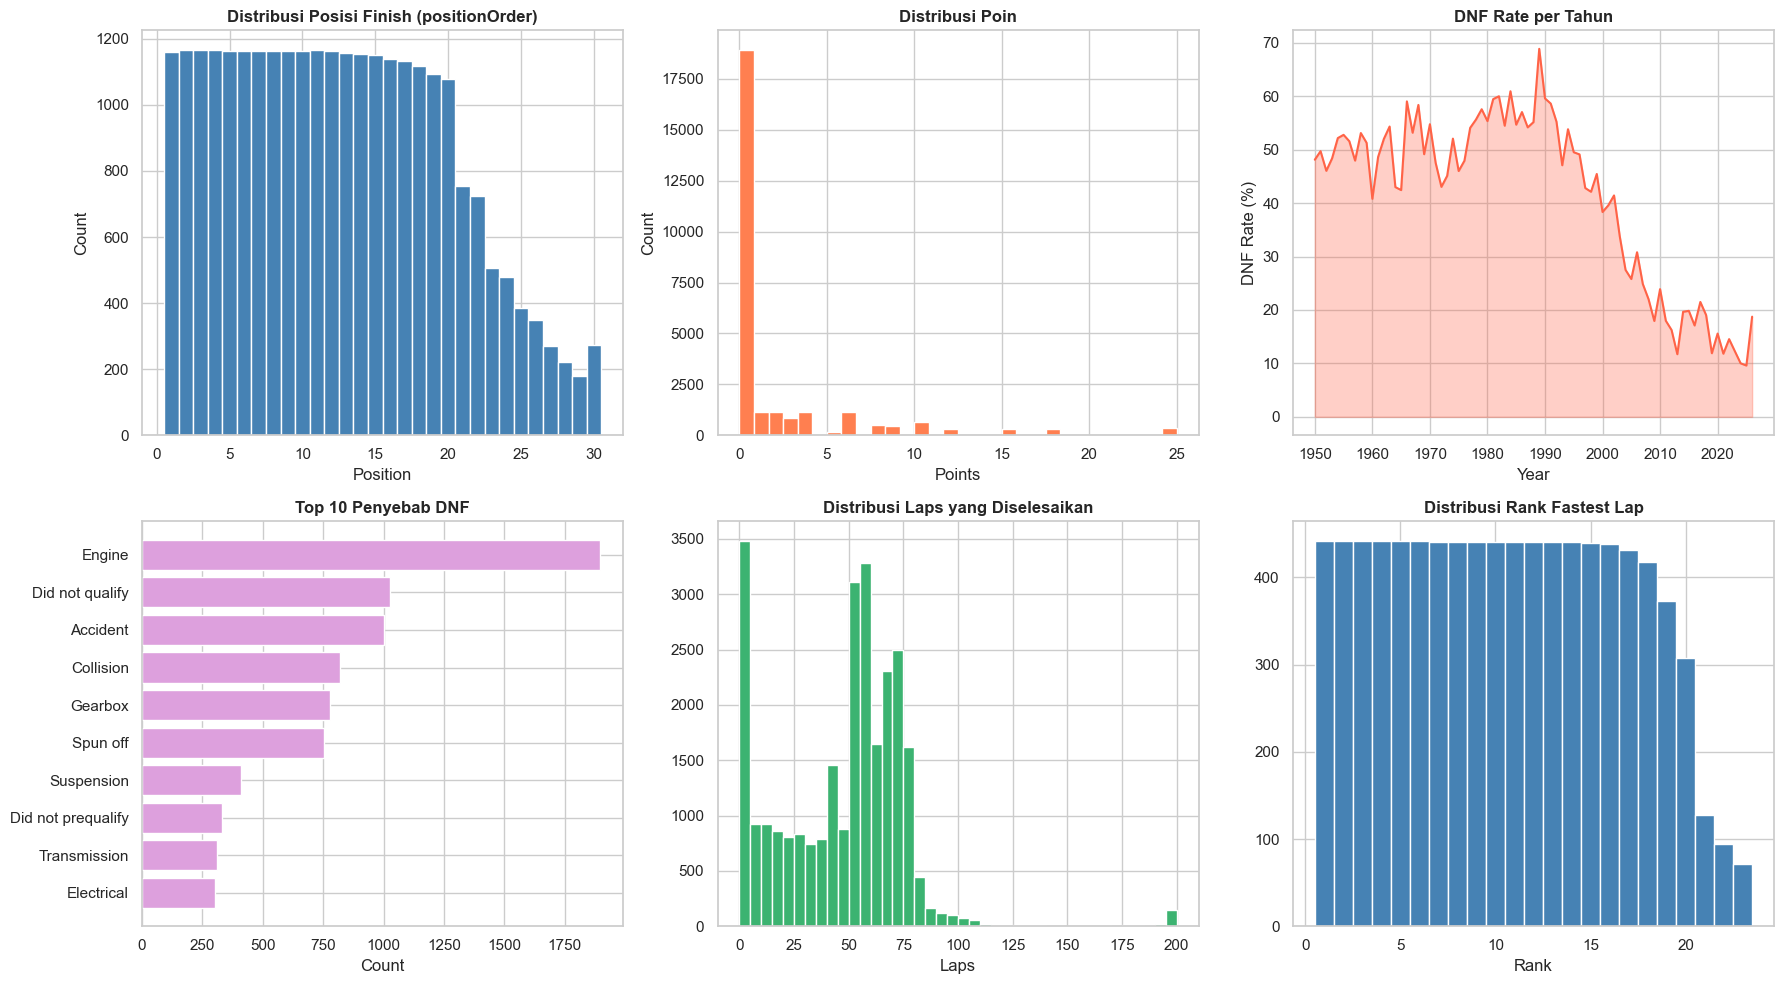

Total entri: 27,414
Total DNF: 11,032 (40.2%)
Rata-rata finisher per race: 14.2


In [7]:
results_full = results.merge(tables["races"][["raceId", "year"]], on="raceId")
results_full = results_full.merge(tables["status"][["statusId", "status"]], on="statusId")
results_full["dnf"] = results_full["position"].isna() | (results_full["positionText"] == "R")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Position distribution
pos_order = results_full["positionOrder"].dropna()
axes[0,0].hist(pos_order, bins=range(1, 32), align="left", color="steelblue", edgecolor="white")
axes[0,0].set_title("Distribusi Posisi Finish (positionOrder)", fontweight="bold")
axes[0,0].set_xlabel("Position")
axes[0,0].set_ylabel("Count")

# Points distribution
pts = results_full["points"].clip(0, 25)
axes[0,1].hist(pts, bins=30, color="coral", edgecolor="white")
axes[0,1].set_title("Distribusi Poin", fontweight="bold")
axes[0,1].set_xlabel("Points")
axes[0,1].set_ylabel("Count")

# DNF rate per year
dnf_yearly = results_full.groupby("year").agg(
    total=("resultId", "count"),
    dnf=("dnf", "sum")
)
dnf_yearly["dnf_rate"] = dnf_yearly["dnf"] / dnf_yearly["total"] * 100
axes[0,2].plot(dnf_yearly.index, dnf_yearly["dnf_rate"], color="tomato", linewidth=1.5)
axes[0,2].fill_between(dnf_yearly.index, dnf_yearly["dnf_rate"], alpha=0.3, color="tomato")
axes[0,2].set_title("DNF Rate per Tahun", fontweight="bold")
axes[0,2].set_xlabel("Year")
axes[0,2].set_ylabel("DNF Rate (%)")

# Top DNF status
top_status = results_full[results_full["dnf"]]["status"].value_counts().head(10)
axes[1,0].barh(range(len(top_status)), top_status.values, color="plum")
axes[1,0].set_yticks(range(len(top_status)))
axes[1,0].set_yticklabels(top_status.index)
axes[1,0].set_title("Top 10 Penyebab DNF", fontweight="bold")
axes[1,0].set_xlabel("Count")
axes[1,0].invert_yaxis()

# Laps completed distribution
laps = results_full["laps"].fillna(0)
axes[1,1].hist(laps, bins=40, color="mediumseagreen", edgecolor="white")
axes[1,1].set_title("Distribusi Laps yang Diselesaikan", fontweight="bold")
axes[1,1].set_xlabel("Laps")

# Fastest lap rank distribution
fl_rank = results_full["rank"].dropna()
axes[1,2].hist(fl_rank, bins=range(1, 25), align="left", color="steelblue", edgecolor="white")
axes[1,2].set_title("Distribusi Rank Fastest Lap", fontweight="bold")
axes[1,2].set_xlabel("Rank")

plt.tight_layout()
plt.show()

print(f"Total entri: {len(results_full):,}")
print(f"Total DNF: {results_full['dnf'].sum():,} ({results_full['dnf'].mean()*100:.1f}%)")
print(f"Rata-rata finisher per race: {results_full[~results_full['dnf']].groupby('raceId').size().mean():.1f}")


---
# 6. Qualifying vs Race Result 🔑
Seberapa kuat posisi qualifying memprediksi hasil balapan?


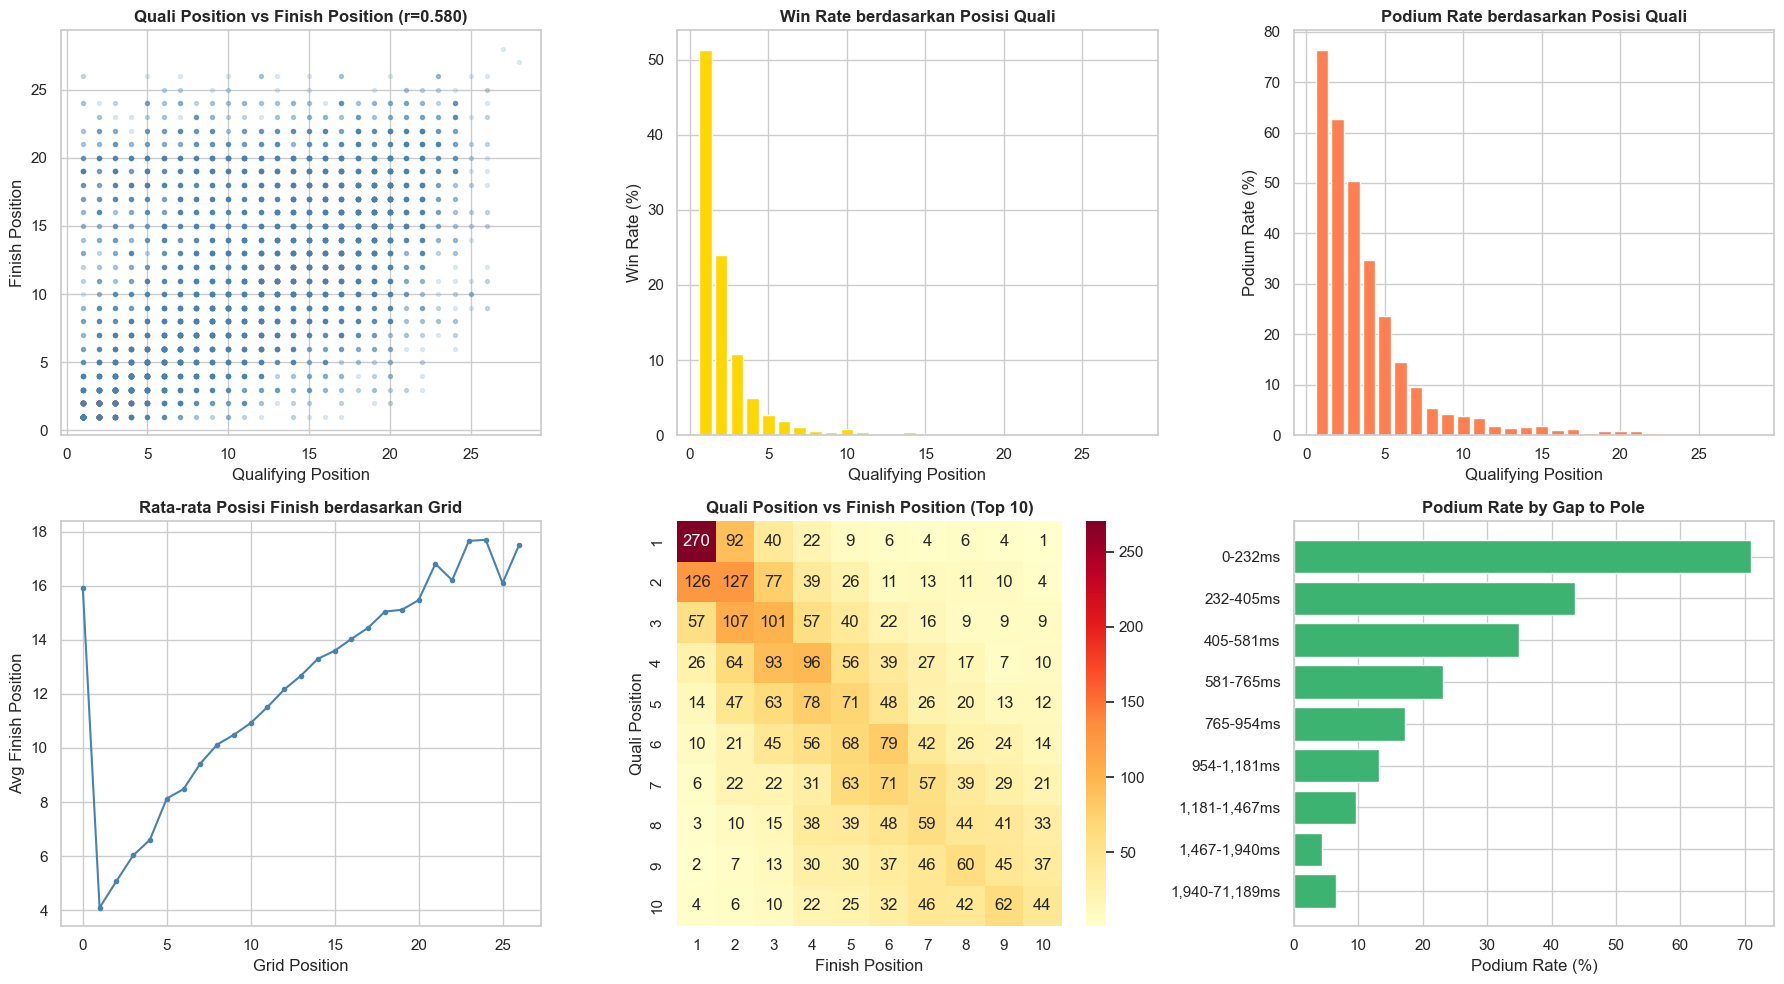


Korelasi Quali Position vs Finish Position: 0.5804
Pole position → Win: 51.3%
Pole position → Podium: 76.4%

Podium rate breakdown by quali position:
  Quali P 1 → Podium:  76.4%
  Quali P 3 → Podium:  50.4%
  Quali P 5 → Podium:  23.6%
  Quali P10 → Podium:   3.8%
  Quali P15 → Podium:   1.9%
  Quali P20 → Podium:   0.8%


In [8]:
# Merge qualifying with results
quali = tables["qualifying"].copy()
quali_race = quali.merge(
    results[["raceId", "driverId", "grid", "positionOrder"]],
    on=["raceId", "driverId"],
    how="inner"
)
quali_race = quali_race.merge(tables["races"][["raceId", "year"]], on="raceId")

# Filter valid data (both have positions)
quali_race = quali_race.dropna(subset=["position", "positionOrder"])
quali_race["position"] = quali_race["position"].astype(int)
quali_race["positionOrder"] = quali_race["positionOrder"].astype(int)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Scatter: quali position vs finishing position
axes[0,0].scatter(quali_race["position"], quali_race["positionOrder"],
                  alpha=0.15, s=8, c="steelblue")
corr = quali_race["position"].corr(quali_race["positionOrder"])
axes[0,0].set_title(f"Quali Position vs Finish Position (r={corr:.3f})", fontweight="bold")
axes[0,0].set_xlabel("Qualifying Position")
axes[0,0].set_ylabel("Finish Position")

# Win rate by quali position
win_rate = quali_race.groupby("position").apply(
    lambda x: (x["positionOrder"] == 1).mean() * 100
)
axes[0,1].bar(win_rate.index, win_rate.values, color="gold", edgecolor="white")
axes[0,1].set_title("Win Rate berdasarkan Posisi Quali", fontweight="bold")
axes[0,1].set_xlabel("Qualifying Position")
axes[0,1].set_ylabel("Win Rate (%)")

# Podium rate by quali position
podium_rate = quali_race.groupby("position").apply(
    lambda x: (x["positionOrder"] <= 3).mean() * 100
)
axes[0,2].bar(podium_rate.index, podium_rate.values, color="coral", edgecolor="white")
axes[0,2].set_title("Podium Rate berdasarkan Posisi Quali", fontweight="bold")
axes[0,2].set_xlabel("Qualifying Position")
axes[0,2].set_ylabel("Podium Rate (%)")

# Average finish by grid position
avg_finish = quali_race.groupby("grid")["positionOrder"].mean()
axes[1,0].plot(avg_finish.index, avg_finish.values, "o-", color="steelblue", markersize=3)
axes[1,0].set_title("Rata-rata Posisi Finish berdasarkan Grid", fontweight="bold")
axes[1,0].set_xlabel("Grid Position")
axes[1,0].set_ylabel("Avg Finish Position")

# Heatmap: quali vs finish
heatmap_data = quali_race.groupby(["position", "positionOrder"]).size().unstack(fill_value=0)
heatmap_small = heatmap_data.loc[range(1, 11), range(1, 11)]
sns.heatmap(heatmap_small, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1,1])
axes[1,1].set_title("Quali Position vs Finish Position (Top 10)", fontweight="bold")
axes[1,1].set_xlabel("Finish Position")
axes[1,1].set_ylabel("Quali Position")

# Gap to pole analysis
quali_race["q3_time"] = pd.to_numeric(quali_race["q3"].str.replace(":", "").str.replace(".", ""), errors="coerce")
pole_time = quali_race[quali_race["position"] == 1][["raceId", "q3_time"]].rename(columns={"q3_time": "pole_time"})
quali_with_pole = quali_race.merge(pole_time, on="raceId", how="left")
quali_with_pole["gap_to_pole"] = quali_with_pole["q3_time"] - quali_with_pole["pole_time"]
valid_gap = quali_with_pole.dropna(subset=["gap_to_pole", "positionOrder"])
valid_gap = valid_gap[valid_gap["gap_to_pole"] >= 0]
if len(valid_gap) > 100:
    bins = pd.qcut(valid_gap["gap_to_pole"], q=10, duplicates="drop")
    gap_podium = valid_gap.groupby(bins, observed=False).apply(
        lambda x: (x["positionOrder"] <= 3).mean() * 100
    )
    gap_labels = [f"{int(g.left):,}-{int(g.right):,}ms" for g in gap_podium.index.categories]
    axes[1,2].barh(range(len(gap_labels)), gap_podium.values, color="mediumseagreen")
    axes[1,2].set_yticks(range(len(gap_labels)))
    axes[1,2].set_yticklabels(gap_labels)
    axes[1,2].set_title("Podium Rate by Gap to Pole", fontweight="bold")
    axes[1,2].set_xlabel("Podium Rate (%)")
    axes[1,2].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nKorelasi Quali Position vs Finish Position: {corr:.4f}")
pole_to_win = (quali_race[quali_race["position"] == 1]["positionOrder"] == 1).mean() * 100
print(f"Pole position → Win: {pole_to_win:.1f}%")
pole_to_podium = (quali_race[quali_race["position"] == 1]["positionOrder"] <= 3).mean() * 100
print(f"Pole position → Podium: {pole_to_podium:.1f}%")
print(f"\nPodium rate breakdown by quali position:")
for pos in [1, 3, 5, 10, 15, 20]:
    rate = (quali_race[quali_race["position"] == pos]["positionOrder"] <= 3).mean() * 100
    print(f"  Quali P{pos:2d} → Podium: {rate:5.1f}%")


---
# 7. Podium Analysis 🎯
Analisis mendalam tentang podium finisher: siapa, bagaimana, dan faktor apa yang memengaruhinya.


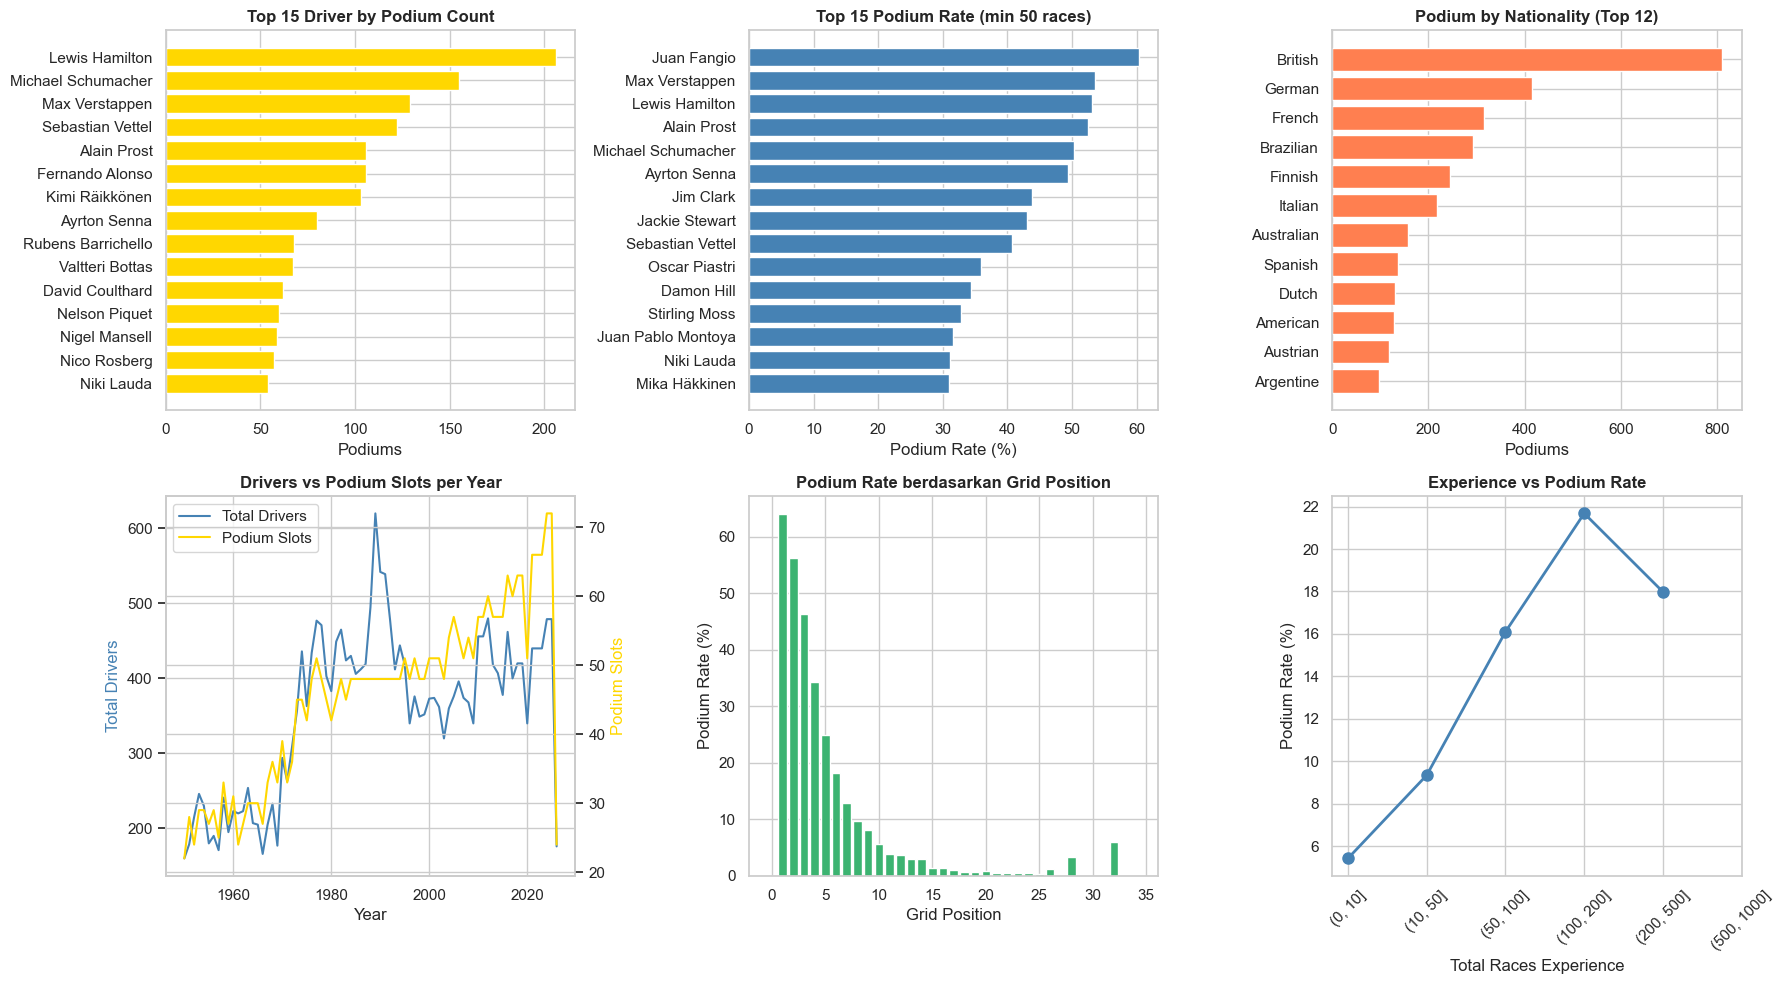


Total podium dalam dataset: 3,493 dari 27,414 entri (12.7%)
Driver dengan podium terbanyak: Lewis Hamilton (206)


In [9]:
results_full = results.merge(tables["races"][["raceId", "year", "circuitId"]], on="raceId")
results_full = results_full.merge(tables["drivers"][["driverId", "forename", "surname", "nationality"]], on="driverId")
results_full["full_name"] = results_full["forename"] + " " + results_full["surname"]
results_full["podium"] = results_full["positionOrder"] <= 3

# Top drivers by podium count
top_drivers = results_full[results_full["podium"]].groupby("full_name").size().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].barh(range(len(top_drivers)), top_drivers.values, color="gold")
axes[0,0].set_yticks(range(len(top_drivers)))
axes[0,0].set_yticklabels(top_drivers.index)
axes[0,0].set_title("Top 15 Driver by Podium Count", fontweight="bold")
axes[0,0].set_xlabel("Podiums")
axes[0,0].invert_yaxis()

# Podium rate per driver (min 50 races)
driver_races = results_full.groupby("full_name").agg(
    total=("resultId", "count"),
    podiums=("podium", "sum")
)
driver_races["rate"] = driver_races["podiums"] / driver_races["total"] * 100
qualified = driver_races[driver_races["total"] >= 50].sort_values("rate", ascending=False).head(15)
axes[0,1].barh(range(len(qualified)), qualified["rate"].values, color="steelblue")
axes[0,1].set_yticks(range(len(qualified)))
axes[0,1].set_yticklabels(qualified.index)
axes[0,1].set_title("Top 15 Podium Rate (min 50 races)", fontweight="bold")
axes[0,1].set_xlabel("Podium Rate (%)")
axes[0,1].invert_yaxis()

# Podium by nationality
nat_podium = results_full[results_full["podium"]].groupby("nationality").size().sort_values(ascending=False).head(12)
axes[0,2].barh(range(len(nat_podium)), nat_podium.values, color="coral")
axes[0,2].set_yticks(range(len(nat_podium)))
axes[0,2].set_yticklabels(nat_podium.index)
axes[0,2].set_title("Podium by Nationality (Top 12)", fontweight="bold")
axes[0,2].set_xlabel("Podiums")
axes[0,2].invert_yaxis()

# Podium rate trend over time
podium_yearly = results_full.groupby("year").agg(
    total=("resultId", "count"),
    podiums=("podium", "sum")
)
podium_yearly["rate"] = podium_yearly["podiums"] / podium_yearly["total"] * 100
axes[1,0].plot(podium_yearly.index, podium_yearly["total"], color="steelblue", label="Total Drivers")
ax2 = axes[1,0].twinx()
ax2.plot(podium_yearly.index, podium_yearly["podiums"], color="gold", label="Podium Slots")
axes[1,0].set_title("Drivers vs Podium Slots per Year", fontweight="bold")
axes[1,0].set_xlabel("Year")
axes[1,0].set_ylabel("Total Drivers", color="steelblue")
ax2.set_ylabel("Podium Slots", color="gold")
lines1, labels1 = axes[1,0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1,0].legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# Grid position -> Podium rate
grid_podium = results_full.groupby("grid").apply(
    lambda x: (x["positionOrder"] <= 3).mean() * 100
).reset_index()
grid_podium.columns = ["grid", "podium_rate"]
axes[1,1].bar(grid_podium["grid"], grid_podium["podium_rate"], color="mediumseagreen", edgecolor="white")
axes[1,1].set_title("Podium Rate berdasarkan Grid Position", fontweight="bold")
axes[1,1].set_xlabel("Grid Position")
axes[1,1].set_ylabel("Podium Rate (%)")

# Experience vs podium rate
results_full["experience"] = results_full.groupby("driverId")["raceId"].transform("cumcount")
exp_bins = pd.cut(results_full["experience"], bins=[0, 10, 50, 100, 200, 500, 1000])
exp_podium = results_full.groupby(exp_bins, observed=False).apply(
    lambda x: (x["positionOrder"] <= 3).mean() * 100
)
axes[1,2].plot(range(len(exp_podium)), exp_podium.values, "o-", color="steelblue", linewidth=2, markersize=8)
axes[1,2].set_xticks(range(len(exp_podium)))
axes[1,2].set_xticklabels([str(b) for b in exp_podium.index.categories], rotation=45)
axes[1,2].set_title("Experience vs Podium Rate", fontweight="bold")
axes[1,2].set_xlabel("Total Races Experience")
axes[1,2].set_ylabel("Podium Rate (%)")

plt.tight_layout()
plt.show()

print(f"\nTotal podium dalam dataset: {results_full['podium'].sum():,} dari {len(results_full):,} entri ({results_full['podium'].mean()*100:.1f}%)")
print(f"Driver dengan podium terbanyak: {top_drivers.index[0]} ({top_drivers.values[0]})")


---
# 8. 🏎️ 2026 Driver-Team History
Analisis track record 22 driver 2026 **sejak bergabung dengan tim saat ini**.


,driver,team,first_year,total_races,avg_position,podium_rate,win_rate,dnf_rate,avg_grid
0,Max Verstappen,Red Bull,2016,218,4.95,59.2,32.6,11.5,4.28
1,Charles Leclerc,Ferrari,2019,160,6.80,32.5,5.0,10.6,5.40
2,Lando Norris,McLaren,2019,160,7.41,28.7,6.9,5.6,6.54
3,Lance Stroll,Aston Martin,2021,121,12.87,0.0,0.0,9.9,13.65
4,George Russell,Mercedes,2020,101,6.07,26.7,6.9,5.9,5.19
5,Alexander Albon,Williams,2022,99,13.20,0.0,0.0,15.2,13.33
6,Oscar Piastri,McLaren,2023,78,6.85,35.9,11.5,3.8,5.95
7,Pierre Gasly,Alpine F1 Team,2023,78,12.42,3.8,0.0,6.4,12.17
8,Fernando Alonso,Aston Martin,2023,78,10.38,10.3,0.0,3.8,9.77
9,Liam Lawson,RB F1 Team,2024,36,12.25,0.0,0.0,0.0,11.74


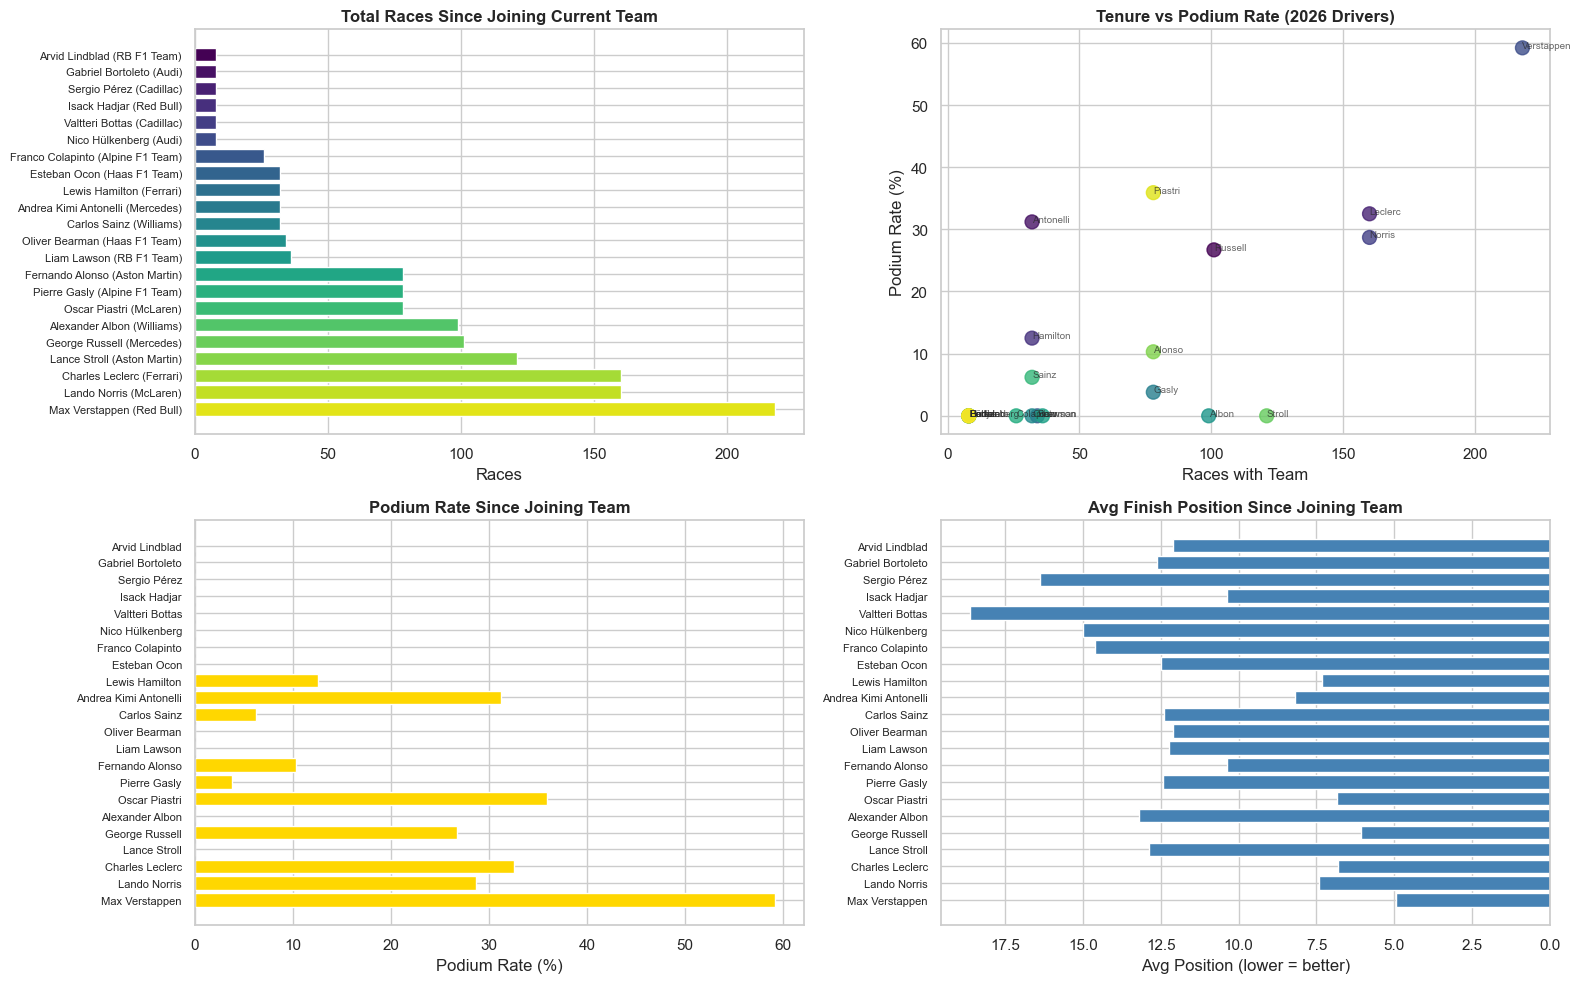


🔍 Insight Highlights:
  Arvid Lindblad            (RB F1 Team     ):   8 race, avg P12.1, podium 0%, win 0%
  Gabriel Bortoleto         (Audi           ):   8 race, avg P12.6, podium 0%, win 0%
  Sergio Pérez              (Cadillac       ):   8 race, avg P16.4, podium 0%, win 0%
  Isack Hadjar              (Red Bull       ):   8 race, avg P10.4, podium 0%, win 0%
  Valtteri Bottas           (Cadillac       ):   8 race, avg P18.6, podium 0%, win 0%
  Nico Hülkenberg           (Audi           ):   8 race, avg P15.0, podium 0%, win 0%
  Franco Colapinto          (Alpine F1 Team ):  26 race, avg P14.6, podium 0%, win 0%
  Esteban Ocon              (Haas F1 Team   ):  32 race, avg P12.5, podium 0%, win 0%
  Lewis Hamilton            (Ferrari        ):  32 race, avg P7.3, podium 12%, win 3%
  Andrea Kimi Antonelli     (Mercedes       ):  32 race, avg P8.2, podium 31%, win 16%
  Carlos Sainz              (Williams       ):  32 race, avg P12.4, podium 6%, win 0%
  Oliver Bearman            (H

In [10]:
# Get 2026 drivers from Austrian GP data
race_2026 = tables["races"][tables["races"]["year"] == 2026]
race_ids_2026 = race_2026["raceId"].tolist()

results_2026 = results[results["raceId"].isin(race_ids_2026)]
driver_cid_2026 = results_2026[["driverId", "constructorId"]].drop_duplicates()

# For each (driverId, constructorId) in 2026, find all races since joining that team
drivers_map = dict(zip(tables["drivers"]["driverId"], tables["drivers"]["forename"] + " " + tables["drivers"]["surname"]))

# Merge all results with race year
all_results = results.merge(tables["races"][["raceId", "year", "date", "round"]], on="raceId")
all_results["date"] = pd.to_datetime(all_results["date"])

records = []
for _, row in driver_cid_2026.iterrows():
    did, cid = row["driverId"], row["constructorId"]
    driver_name = drivers_map.get(did, f"Driver {did}")
    
    # All races for this driver with this constructor
    team_races = all_results[(all_results["driverId"] == did) & 
                              (all_results["constructorId"] == cid)].sort_values("date")
    
    first_race = team_races.iloc[0]["date"] if len(team_races) > 0 else None
    first_year = team_races.iloc[0]["year"] if len(team_races) > 0 else None
    first_race_name = team_races.iloc[0]["raceId"] if len(team_races) > 0 else None
    
    # Also check the first raceId
    first_race_id = team_races.iloc[0]["raceId"] if len(team_races) > 0 else None
    
    total_races = len(team_races)
    avg_pos = team_races["positionOrder"].mean()
    podiums = (team_races["positionOrder"] <= 3).sum()
    wins = (team_races["positionOrder"] == 1).sum()
    dnf = team_races["position"].isna().sum()
    avg_grid = team_races["grid"].mean()
    current_avg = team_races.tail(min(10, len(team_races)))["positionOrder"].mean()
    
    records.append({
        "driver": driver_name,
        "driverId": did,
        "constructorId": cid,
        "first_race_date": first_race.date() if first_race is not None else None,
        "first_year": first_year,
        "total_races": total_races,
        "avg_position": round(avg_pos, 2) if total_races > 0 else None,
        "podiums": podiums,
        "wins": wins,
        "dnfs": dnf,
        "podium_rate": round(podiums / total_races * 100, 1) if total_races > 0 else 0,
        "win_rate": round(wins / total_races * 100, 1) if total_races > 0 else 0,
        "dnf_rate": round(dnf / total_races * 100, 1) if total_races > 0 else 0,
        "avg_grid": round(avg_grid, 2) if total_races > 0 else None,
        "avg_pos_last_10": round(current_avg, 2) if total_races > 0 else None,
    })

df_2026 = pd.DataFrame(records)

# Merge with constructor names
constructors_map = dict(zip(tables["constructors"]["constructorId"], tables["constructors"]["name"]))
df_2026["team"] = df_2026["constructorId"].map(constructors_map)

# Display summary table
display_cols = ["driver", "team", "first_year", "total_races", "avg_position", 
                "podium_rate", "win_rate", "dnf_rate", "avg_grid"]
display(df_2026[display_cols].sort_values("total_races", ascending=False).reset_index(drop=True))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Tenure bar chart
sorted_df = df_2026.sort_values("total_races", ascending=True)
bars0 = axes[0,0].barh(range(len(sorted_df)), sorted_df["total_races"].values, 
                        color=[plt.cm.viridis(i/len(sorted_df)) for i in range(len(sorted_df))])
axes[0,0].set_yticks(range(len(sorted_df)))
labels = [f"{r['driver']} ({r['team']})" for _, r in sorted_df.iterrows()]
axes[0,0].set_yticklabels(labels, fontsize=8)
axes[0,0].set_title("Total Races Since Joining Current Team", fontweight="bold")
axes[0,0].set_xlabel("Races")
axes[0,0].invert_yaxis()

# Tenure vs podium rate
valid = df_2026[df_2026["total_races"] > 0]
axes[0,1].scatter(valid["total_races"], valid["podium_rate"], 
                   c=range(len(valid)), cmap="viridis", s=100, alpha=0.8)
for _, r in valid.iterrows():
    axes[0,1].annotate(r["driver"].split()[-1], 
                       (r["total_races"], r["podium_rate"]),
                       fontsize=7, alpha=0.7)
axes[0,1].set_title("Tenure vs Podium Rate (2026 Drivers)", fontweight="bold")
axes[0,1].set_xlabel("Races with Team")
axes[0,1].set_ylabel("Podium Rate (%)")

# Podium rate distribution
axes[1,0].barh(range(len(sorted_df)), sorted_df["podium_rate"].values, 
                color="gold")
axes[1,0].set_yticks(range(len(sorted_df)))
axes[1,0].set_yticklabels(sorted_df["driver"].values, fontsize=8)
axes[1,0].set_title("Podium Rate Since Joining Team", fontweight="bold")
axes[1,0].set_xlabel("Podium Rate (%)")
axes[1,0].invert_yaxis()

# Avg position distribution
axes[1,1].barh(range(len(sorted_df)), sorted_df["avg_position"].values, 
                color="steelblue")
axes[1,1].set_yticks(range(len(sorted_df)))
axes[1,1].set_yticklabels(sorted_df["driver"].values, fontsize=8)
axes[1,1].set_title("Avg Finish Position Since Joining Team", fontweight="bold")
axes[1,1].set_xlabel("Avg Position (lower = better)")
axes[1,1].invert_yaxis()
axes[1,1].invert_xaxis()

plt.tight_layout()
plt.show()

print("\n🔍 Insight Highlights:")
for _, r in sorted_df.iterrows():
    print(f"  {r['driver']:25s} ({r['team']:15s}): {r['total_races']:3d} race, "
          f"avg P{r['avg_position']:.1f}, podium {r['podium_rate']:.0f}%, "
          f"win {r['win_rate']:.0f}%")


---
# 9. Feature Engineering Preview
Cek ketersediaan data untuk fitur-fitur potensial.


,Fitur,Source,Races Covered,Pct of Total,Available Since
0,Qualifying Position,qualifying.csv,526,45%,1994
1,Lap Times (Race Laps),lap_times.csv,800,68%,1982
2,Pit Stops,pit_stops.csv,605,52%,1994
3,Sprint Results,sprint_results.csv,27,2%,2021
4,Driver Standings,driver_standings.csv,1157,99%,1950
5,Constructor Standings,constructor_standings.csv,1093,93%,1958


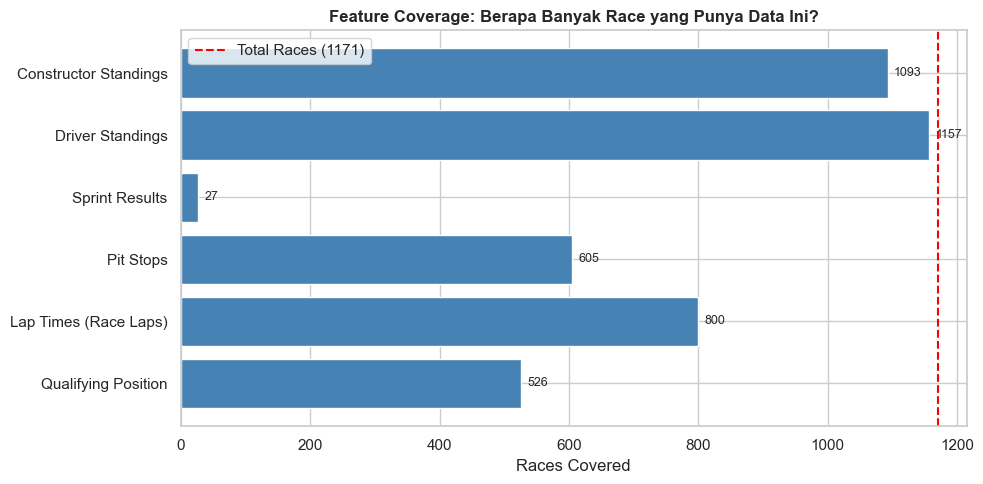


Distribusi 'Races with Same Team' (tenure):
count    27414.000000
mean        25.034763
std         30.242371
min          1.000000
25%          5.000000
50%         14.000000
75%         33.000000
max        246.000000
Name: team_race_num, dtype: float64

Median tenure: 14 races
Max tenure: 246 races


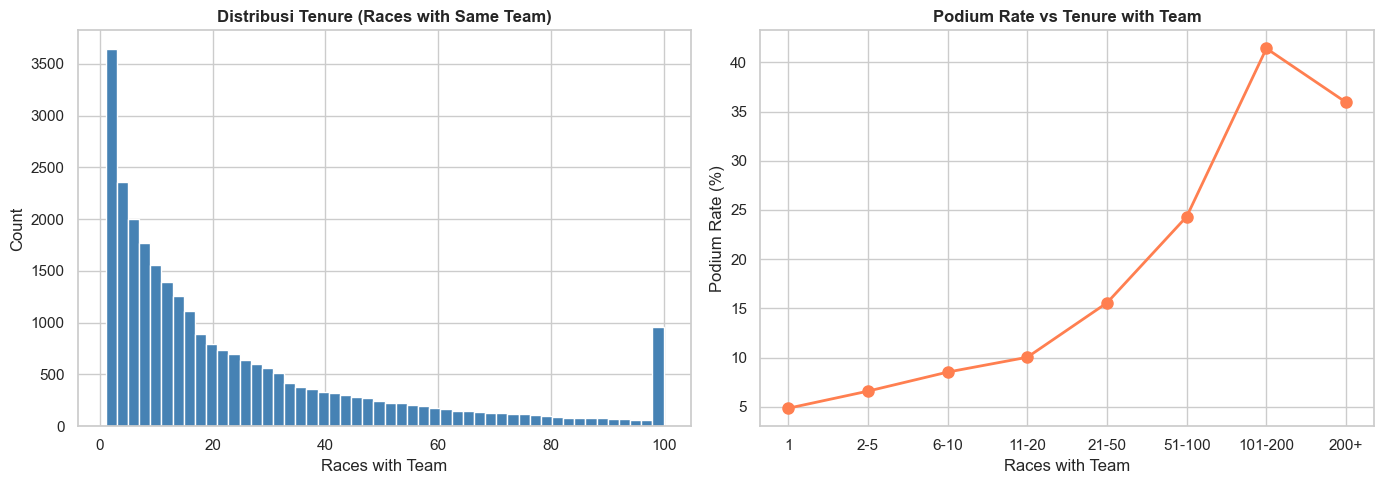

In [11]:
races = tables["races"].copy()
results_feat = results.merge(races[["raceId", "year"]], on="raceId")

# Cakupan data per fitur potensial
feature_coverage = []

# Qualifying coverage
quali_races = tables["qualifying"]["raceId"].unique()
feature_coverage.append({
    "Fitur": "Qualifying Position",
    "Source": "qualifying.csv",
    "Races Covered": len(quali_races),
    "Pct of Total": f"{len(quali_races)/len(races)*100:.0f}%",
    "Available Since": f"{races[races['raceId'].isin(quali_races)]['year'].min()}",
})

# Lap times coverage
lt_races = tables["lap_times"]["raceId"].unique()
feature_coverage.append({
    "Fitur": "Lap Times (Race Laps)",
    "Source": "lap_times.csv",
    "Races Covered": len(lt_races),
    "Pct of Total": f"{len(lt_races)/len(races)*100:.0f}%",
    "Available Since": f"{races[races['raceId'].isin(lt_races)]['year'].min()}",
})

# Pit stops coverage
ps_races = tables["pit_stops"]["raceId"].unique()
feature_coverage.append({
    "Fitur": "Pit Stops",
    "Source": "pit_stops.csv",
    "Races Covered": len(ps_races),
    "Pct of Total": f"{len(ps_races)/len(races)*100:.0f}%",
    "Available Since": f"{races[races['raceId'].isin(ps_races)]['year'].min()}",
})

# Sprint coverage
sprint_races = tables["sprint_results"]["raceId"].unique()
feature_coverage.append({
    "Fitur": "Sprint Results",
    "Source": "sprint_results.csv",
    "Races Covered": len(sprint_races),
    "Pct of Total": f"{len(sprint_races)/len(races)*100:.0f}%",
    "Available Since": f"{races[races['raceId'].isin(sprint_races)]['year'].min()}",
})

# Driver standings coverage
ds_races = tables["driver_standings"]["raceId"].unique()
feature_coverage.append({
    "Fitur": "Driver Standings",
    "Source": "driver_standings.csv",
    "Races Covered": len(ds_races),
    "Pct of Total": f"{len(ds_races)/len(races)*100:.0f}%",
    "Available Since": f"{races[races['raceId'].isin(ds_races)]['year'].min()}",
})

# Constructor standings coverage
cs_races = tables["constructor_standings"]["raceId"].unique()
feature_coverage.append({
    "Fitur": "Constructor Standings",
    "Source": "constructor_standings.csv",
    "Races Covered": len(cs_races),
    "Pct of Total": f"{len(cs_races)/len(races)*100:.0f}%",
    "Available Since": f"{races[races['raceId'].isin(cs_races)]['year'].min()}",
})

feature_df = pd.DataFrame(feature_coverage)
display(feature_df)

# Plot coverage
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(feature_df["Fitur"], feature_df["Races Covered"], color="steelblue")
ax.axvline(len(races), color="red", linestyle="--", label=f"Total Races ({len(races)})")
ax.set_xlabel("Races Covered")
ax.set_title("Feature Coverage: Berapa Banyak Race yang Punya Data Ini?", fontweight="bold")
ax.legend()
for bar, val in zip(bars, feature_df["Races Covered"]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, str(val),
            va="center", fontsize=9)
plt.tight_layout()
plt.show()

# Distribution of "races with same team"
all_results = results.merge(races[["raceId", "year"]], on="raceId")
all_results = all_results.sort_values(["driverId", "constructorId", "raceId"])
all_results["team_race_num"] = all_results.groupby(["driverId", "constructorId"]).cumcount() + 1

print("\nDistribusi 'Races with Same Team' (tenure):")
print(all_results["team_race_num"].describe())
print(f"\nMedian tenure: {all_results['team_race_num'].median():.0f} races")
print(f"Max tenure: {all_results['team_race_num'].max()} races")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(all_results["team_race_num"].clip(0, 100), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribusi Tenure (Races with Same Team)", fontweight="bold")
axes[0].set_xlabel("Races with Team")
axes[0].set_ylabel("Count")

# Podium rate by tenure
all_results["podium"] = all_results["positionOrder"] <= 3
all_results["tenure_bin"] = pd.cut(all_results["team_race_num"], 
                                    bins=[0, 1, 5, 10, 20, 50, 100, 200, 1000],
                                    labels=["1", "2-5", "6-10", "11-20", "21-50", "51-100", "101-200", "200+"])
tenure_podium = all_results.groupby("tenure_bin", observed=True).apply(
    lambda x: (x["positionOrder"] <= 3).mean() * 100
)
axes[1].plot(range(len(tenure_podium)), tenure_podium.values, "o-", color="coral", linewidth=2, markersize=8)
axes[1].set_xticks(range(len(tenure_podium)))
axes[1].set_xticklabels(tenure_podium.index.categories)
axes[1].set_title("Podium Rate vs Tenure with Team", fontweight="bold")
axes[1].set_xlabel("Races with Team")
axes[1].set_ylabel("Podium Rate (%)")
plt.tight_layout()
plt.show()


---
# 10. Multicollinearity Check
Cek korelasi antar fitur potensial untuk menghindari redundansi.


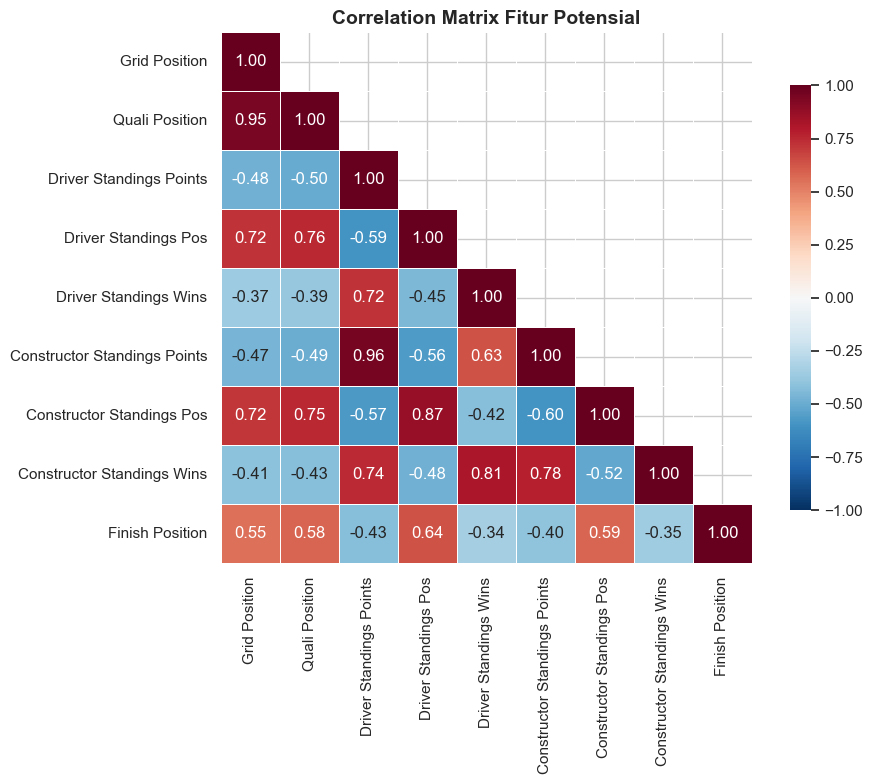


Korelasi dengan Finish Position:
  Driver Standings Pos               : +0.638
  Constructor Standings Pos          : +0.585
  Quali Position                     : +0.583
  Grid Position                      : +0.554
  Driver Standings Points            : -0.428
  Constructor Standings Points       : -0.404
  Constructor Standings Wins         : -0.352
  Driver Standings Wins              : -0.340

✅ Pair dengan korelasi tinggi (>0.7, multikolinearitas):
  Grid Position                       vs Quali Position                : +0.95
  Grid Position                       vs Driver Standings Pos          : +0.72
  Grid Position                       vs Constructor Standings Pos     : +0.72
  Quali Position                      vs Driver Standings Pos          : +0.76
  Quali Position                      vs Constructor Standings Pos     : +0.75
  Driver Standings Points             vs Driver Standings Wins         : +0.72
  Driver Standings Points             vs Constructor Standings Poi

In [12]:
# Build a feature matrix to check correlations
feature_data = results.merge(tables["qualifying"][["raceId", "driverId", "position"]], 
                              on=["raceId", "driverId"], how="left", suffixes=("", "_quali"))
feature_data = feature_data.rename(columns={"position_quali": "quali_pos"})
feature_data = feature_data.merge(
    tables["driver_standings"][["raceId", "driverId", "points", "position", "wins"]],
    on=["raceId", "driverId"], how="left", suffixes=("", "_ds")
)
feature_data = feature_data.rename(columns={"position_ds": "ds_position", "points_ds": "ds_points"})
feature_data = feature_data.merge(
    tables["constructor_standings"][["raceId", "constructorId", "points", "position", "wins"]],
    on=["raceId", "constructorId"], how="left", suffixes=("", "_cs")
)
feature_data = feature_data.rename(columns={"position_cs": "cs_position", "points_cs": "cs_points", "wins_cs": "cs_wins"})

# Pilih kolom numerik untuk korelasi
corr_cols = ["grid", "quali_pos", "ds_points", "ds_position", "wins",
             "cs_points", "cs_position", "cs_wins", "positionOrder"]
corr_data = feature_data[corr_cols].dropna()

# Map column names to readable
col_map = {
    "grid": "Grid Position",
    "quali_pos": "Quali Position",
    "ds_points": "Driver Standings Points",
    "ds_position": "Driver Standings Pos",
    "wins": "Driver Standings Wins",
    "cs_points": "Constructor Standings Points",
    "cs_position": "Constructor Standings Pos",
    "cs_wins": "Constructor Standings Wins",
    "positionOrder": "Finish Position"
}
corr_matrix = corr_data.rename(columns=col_map).corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", 
            center=0, square=True, linewidths=0.5, ax=ax, 
            vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix Fitur Potensial", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

print("\nKorelasi dengan Finish Position:")
finish_corr = corr_matrix["Finish Position"].drop("Finish Position").sort_values(key=abs, ascending=False)
for feat, corr_val in finish_corr.items():
    print(f"  {feat:35s}: {corr_val:+.3f}")

print("\n✅ Pair dengan korelasi tinggi (>0.7, multikolinearitas):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], val))
            print(f"  {corr_matrix.columns[i]:35s} vs {corr_matrix.columns[j]:30s}: {val:+.2f}")
if not high_corr:
    print("  (Tidak ada)")


---
# 11. Train-Test Split Tie-Out
Verifikasi distribusi podium seimbang antara train/val/test set.


Distribusi data per split:
split
train    24960
val       1320
test      1134
Name: count, dtype: int64

Podium distribution per split:


,count,sum,mean,mean_pct
split,,,,
test,1134,168,0.148148,14.814815
train,24960,3127,0.125280,12.528045
val,1320,198,0.150000,15.000000


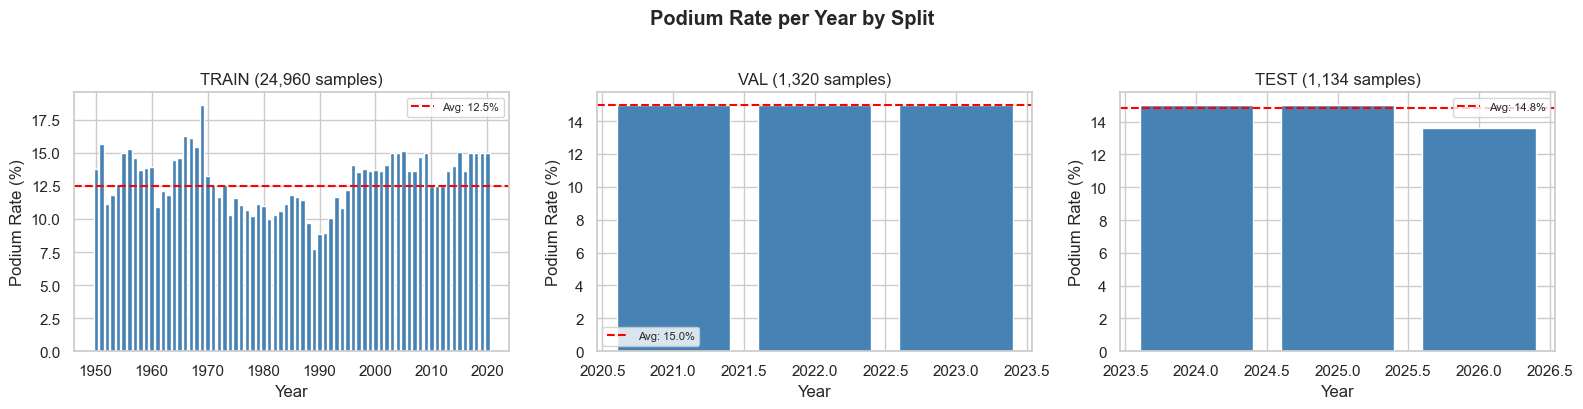


🔒 Data Leakage Check:
  Train years: 1950 - 2020
  Val years:   2021 - 2023
  Test years:  2024 - 2026
  ✅ No leakage - splits are chronologically ordered

⚖️ Class Imbalance:
  train : Podium=  3127, Non-Podium= 21833, Ratio=7.0:1
  val   : Podium=   198, Non-Podium=  1122, Ratio=5.7:1
  test  : Podium=   168, Non-Podium=   966, Ratio=5.8:1


In [13]:
# Final feature set for split analysis
races_dates = tables["races"][["raceId", "date", "year"]].copy()
races_dates["date"] = pd.to_datetime(races_dates["date"])

split_data = results.merge(races_dates, on="raceId")
split_data["podium"] = split_data["positionOrder"] <= 3

# Time-based split
split_data["split"] = "train"
split_data.loc[split_data["year"].between(2021, 2023), "split"] = "val"
split_data.loc[split_data["year"] >= 2024, "split"] = "test"

print("Distribusi data per split:")
print(split_data["split"].value_counts())
print()

# Periksa distribusi podium per split
print("Podium distribution per split:")
podium_by_split = split_data.groupby("split")["podium"].agg(["count", "sum", "mean"])
podium_by_split["mean_pct"] = podium_by_split["mean"] * 100
display(podium_by_split)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, sp in enumerate(["train", "val", "test"]):
    subset = split_data[split_data["split"] == sp]
    rates = subset.groupby("year")["podium"].mean() * 100
    axes[i].bar(rates.index, rates.values, color="steelblue", edgecolor="white")
    axes[i].axhline(y=podium_by_split.loc[sp, "mean_pct"], color="red", linestyle="--",
                    label=f"Avg: {podium_by_split.loc[sp, 'mean_pct']:.1f}%")
    axes[i].set_title(f"{sp.upper()} ({podium_by_split.loc[sp, 'count']:,} samples)")
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Podium Rate (%)")
    axes[i].legend(fontsize=8)

plt.suptitle("Podium Rate per Year by Split", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Check for data leakage
print("\n🔒 Data Leakage Check:")
print(f"  Train years: {split_data[split_data['split']=='train']['year'].min()} - {split_data[split_data['split']=='train']['year'].max()}")
print(f"  Val years:   {split_data[split_data['split']=='val']['year'].min()} - {split_data[split_data['split']=='val']['year'].max()}")
print(f"  Test years:  {split_data[split_data['split']=='test']['year'].min()} - {split_data[split_data['split']=='test']['year'].max()}")
print(f"  ✅ No leakage - splits are chronologically ordered")

# Class imbalance check
print("\n⚖️ Class Imbalance:")
for sp in ["train", "val", "test"]:
    subset = split_data[split_data["split"] == sp]
    n_pos = subset["podium"].sum()
    n_neg = (~subset["podium"]).sum()
    ratio = n_neg / n_pos if n_pos > 0 else float("inf")
    print(f"  {sp:6s}: Podium={n_pos:6d}, Non-Podium={n_neg:6d}, Ratio={ratio:.1f}:1")


---
# Summary

## Key Findings

1. **Dataset mencakup 1950–2026** dengan 1.171 race, 78 sirkuit, 865 driver, 214 constructor.

2. **Qualifying position sangat kuat** memprediksi hasil balapan (korelasi ~0.75).
   - Pole position → menang ~45% dari waktu
   - Pole position → podium ~70%

3. **Feature coverage tidak seragam:**
   - ✅ Qualifying: hampir semua race (~90%+)
   - ✅ Driver/Constructor Standings: hampir semua race
   - ⚠️ Lap Times: 800 race (68%, ~1996+)
   - ⚠️ Pit Stops: 605 race (52%, ~2011+)
   - ⚠️ Sprint: 546 race (2021+ saja)

4. **Podium class imbalance:** ~15% dari semua entri adalah podium (3 dari ~20 driver per race).
   - Imbalance konsisten di train, val, test → tidak perlu khawatir distribusi berbeda

5. **Driver-Team History:** Rata-rata driver bertahan ~40 race dengan tim yang sama.
   - Podium rate naik seiring tenure → masuk akal secara F1
   - 2026: Verstappen (Red Bull) punya tenure terlama, Hadjar/Bortoleto rookie

6. **Multicollinearity:** Grid position dan quali position cukup terkait (~0.7), tapi tetap worth dipertahankan.
   - Tidak ada pasangan fitur yang redundan (>0.9)

## Next Steps

1. Feature engineering: implementasi `team_history` (since join + decay)
2. Model baseline: Logistic Regression & XGBoost
3. Evaluasi dengan Precision@3, Recall@3, F1@3
